# Capstone --- Combining Predictive Techniques

**Team member:** Ellis Madrigal
**Course:** BANA 620 --- Predictive Analytics & Data Mining  

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 60)

## 1. Problem Statement

LendingClub is an online P2P lending platform. Though it is always risky to lend money, because LendingClub operates outside of the standard banking system, borrower default can have a larger effect on their own financial health. 

The company assigns a letter grade to all loan applications based on their proprietary risk model. A, B, and C are prime loans with better interest rates. D, E, F, and G are subprime loans with higher interest rates.

In this exercise, I am taking on the role of an employee creating a "second-opinion model." The model's job is akin to cross-validation for LendingClub's existing proprietary grading model. The target variable will be a new variable, "risky_grade," that signifies a D, E, F, or G loan. I will create four predictive models, compare their results, and recommend which is fit for production. 

## Load the raw data

In [3]:
loans = pd.read_csv('lending_club_raw.csv')
print('Shape:', loans.shape)
loans.head()

Shape: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


### Inspection: dtypes and missingness

Use the output below to plan your cleaning. Look for:
- columns stored as strings that should be numeric
- columns with heavy missingness

In [4]:
print(loans.dtypes.value_counts())
print()
missing_pct = (loans.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(1))

int64      25
float64    17
object     13
Name: count, dtype: int64

verification_income_joint           85.4
annual_income_joint                 85.0
debt_to_income_joint                85.0
months_since_90d_late               77.1
months_since_last_delinq            56.6
months_since_last_credit_inquiry    12.7
emp_title                            8.3
emp_length                           8.2
num_accounts_120d_past_due           3.2
debt_to_income                       0.2
dtype: float64


## 2. Exploratory Data Analysis

**Required:** at least three visualizations, each with a one- or two-sentence caption.

In [14]:
# target engineering
loans['risky_grade'] = loans['grade'].isin(['D','E','F','G']).astype(int)

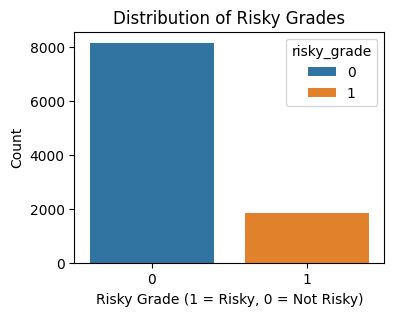

In [13]:
# TODO: visualization 1 --- target distribution
plt.figure(figsize=(4,3))
plt.title('Distribution of Risky Grades')
plt.xlabel('Risky Grade (1 = Risky, 0 = Not Risky)')
plt.ylabel('Count')
sns.countplot(data=loans, x='risky_grade', hue='risky_grade')
plt.show()

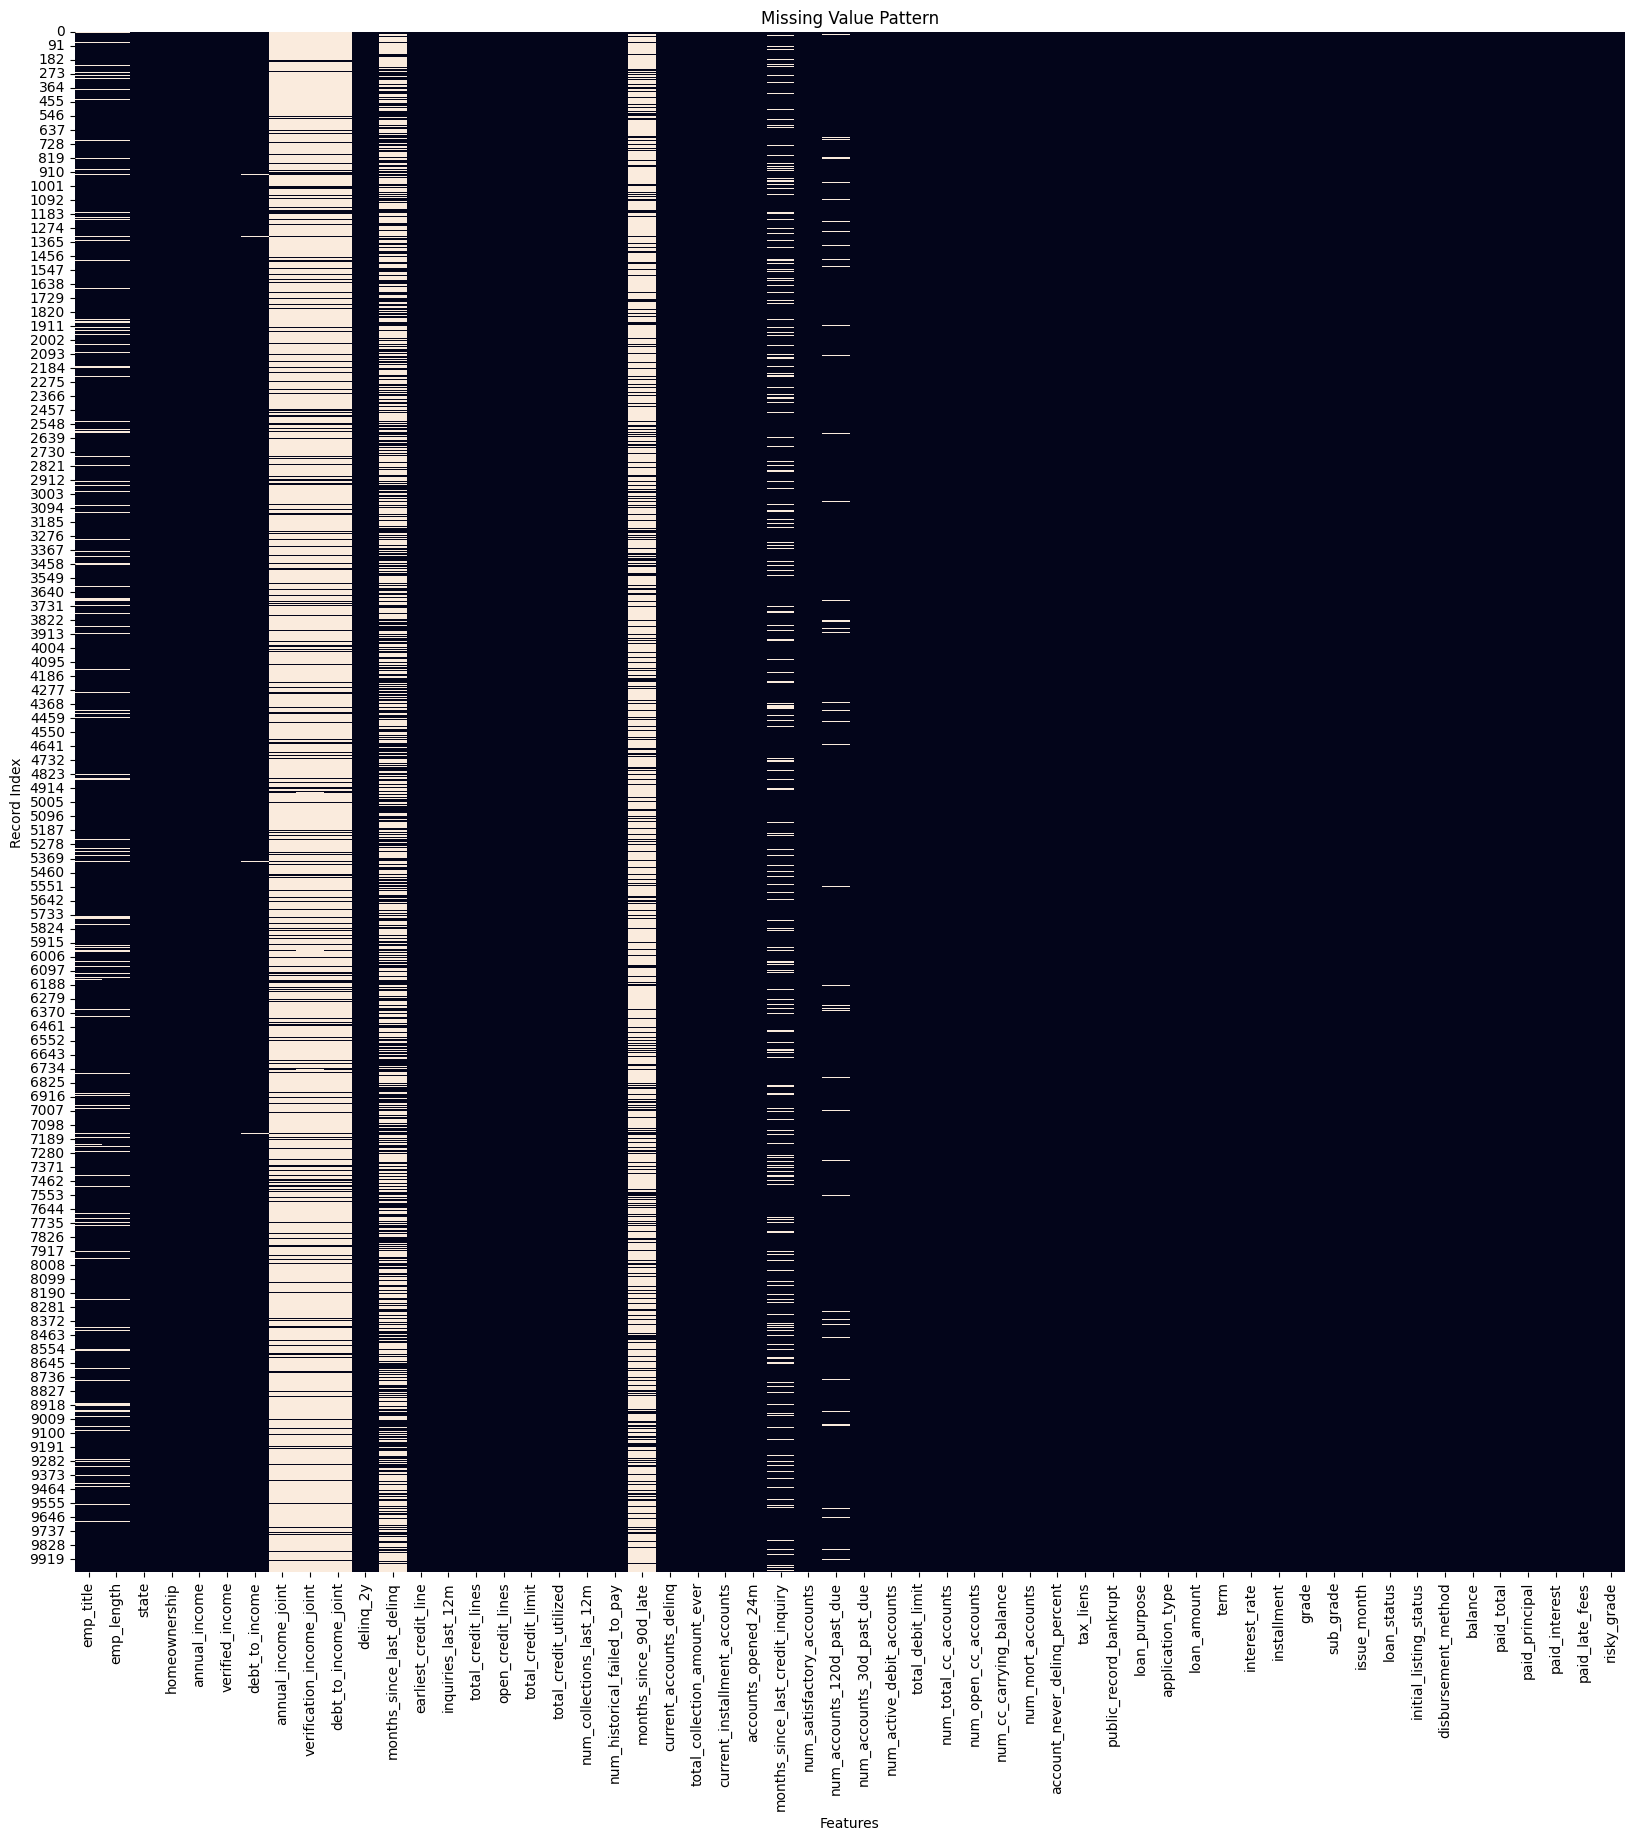

In [15]:
# TODO: visualization 2 --- missing-value pattern

plt.figure(figsize=(20,20))
sns.heatmap(loans.isna(), cbar=False)
plt.title("Missing Value Pattern")
plt.xlabel("Features")
plt.ylabel("Record Index")
plt.show()

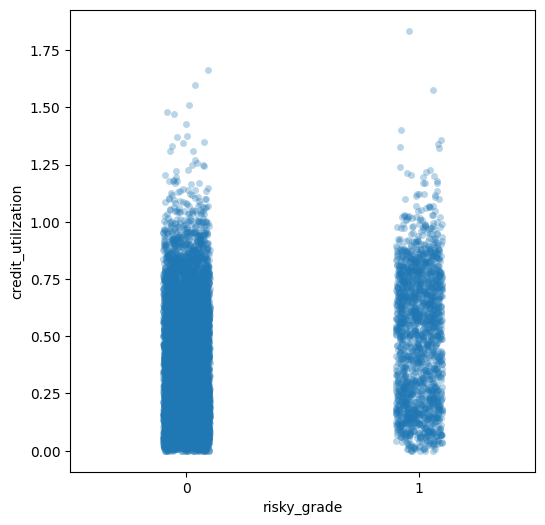

In [38]:
# TODO: visualization 3 --- relationship between a numeric feature and the target

loans['credit_utilization'] = loans['total_credit_utilized'] / loans['total_credit_limit']

plt.figure(figsize=(6,6))
sns.stripplot(data=loans, x='risky_grade', y='credit_utilization', jitter=True, alpha=0.3)
plt.show()

## 3. Data Cleaning

For every cleaning step, write a short markdown cell before the code explaining **what** you did and **why**.

### 3.1 Drop the data-leakage columns

The columns listed in `LEAKAGE_COLUMNS` below are provided explicitly in the project instructions. They are either the target itself (derived from `grade`) or values that Lending Club only records after the loan has been issued. You must remove all of them before training any model.

| Removal Category | Features removed | Explanation |
| --- | --- | --- |
| Target variable multicollinarity | grade, sub_grade, interest_rate | Features are either the source that "risky_grade" is derived from, or are drilled-down details or results from the "grade" column. Keeping them in would introduce multicollinarity with the dependent variable. |
| Derived from removed source | installment | Because "installment" is derived, in part, from "interest_rate," which has to be removed, "installment" must also be removed. |
| Post-approval | loan_status, initial_listing_status, disbursement_method | These features describe the outcome of the first model. Because my model must only consider information included in the application, these attributes need to be removed. |
| Payment history | balance, paid_total, paid_principal, paid_interest, paid_late_fees | Similar to above, these features record the loan's current balance and payment history. They need to be removed in order to only predict based on the initial application. |

In [ ]:
# Explicit leakage columns --- listed in the instructions PDF.
LEAKAGE_COLUMNS = [
    'grade',                  # target is derived from this column
    'sub_grade',              # finer version of grade; same leakage
    'interest_rate',          # set by Lending Club based on grade
    'installment',            # derived from loan_amount, term, interest_rate
    'loan_status',            # post-origination outcome
    'initial_listing_status', # only known after Lending Club approves the loan
    'disbursement_method',    # only known after approval
    'balance',                # post-origination balance
    'paid_total',             # post-origination payment outcome
    'paid_principal',         # post-origination payment outcome
    'paid_interest',          # post-origination payment outcome
    'paid_late_fees',         # post-origination payment outcome
]

loans_clean = loans.drop(columns=LEAKAGE_COLUMNS)

### 3.2 Missing-value strategy

| Imputation strategy | Features | Explanation |
| --- | --- | --- |
| X | x | verification_income_joint           85.4
annual_income_joint                 85.0
debt_to_income_joint                85.0
months_since_90d_late               77.1
months_since_last_delinq            56.6
months_since_last_credit_inquiry    12.7
emp_title                            8.3
emp_length                           8.2
num_accounts_120d_past_due           3.2
debt_to_income                       0.2 |

In [ ]:
# TODO: handle missing values by column group
#   - write a markdown cell before each change explaining the strategy
#   - consider: joint-application columns, months_since_* columns, emp_length, etc.

### 3.3 String-to-numeric conversions and categorical decisions


| Data transformation | Features | Explanation |
| --- | --- | --- |
| String-to-numeric conversions | x | x |
| One-hot encoding | x | x |
| Ordinal encoding | x | x |

In [ ]:
# TODO: convert any text-formatted numeric columns
# TODO: decide on one-hot vs ordinal encoding for each categorical column and justify

## 4. Feature Engineering

Create at least **three new features**. Each needs a one-line rationale in a markdown cell above the code.

| Feature name | Method | Explanation |
| --- | --- | --- |
| x | x | x |
| x | x | x |
| x | x | x |

In [ ]:
loans['credit_utilization'] = loans['total_credit_utilized'] / loans['total_credit_limit']

# TODO: feature 2
# TODO: feature 3

## 5. Train/Test Split

80/20 split with `random_state=42`. **Split before** fitting any scaling or imputation.

In [ ]:
# TODO: define X (features) and y (target), then do an 80/20 split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
# )
# print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
# print('Train base rate:', y_train.mean().round(3), ' Test base rate:', y_test.mean().round(3))

## 6. Model Training

Train the four required models with identical preprocessing. Tip: build a `ColumnTransformer` that scales numeric columns and one-hot-encodes categorical columns, then plug it into a `Pipeline` per model.

In [ ]:
# TODO: build the shared preprocessor (ColumnTransformer)
# numeric_features = ...
# categorical_features = ...
# preprocessor = ColumnTransformer(...)

In [ ]:
# TODO: model 1 --- Logistic Regression (L2)

In [ ]:
# TODO: model 2 --- Decision Tree (pre-pruned with max_depth and min_samples_leaf)

In [ ]:
# TODO: model 3 --- Neural Network (MLPClassifier, one hidden layer, scaled inputs)

In [ ]:
# TODO: model 4 --- Random Forest OR Gradient Boosting (pick one)

## 7. Evaluation

Produce a single comparison table and one overlaid ROC-curve figure.

In [ ]:
# TODO: build the metric comparison table
# results = pd.DataFrame({
#     'Model': ['Logistic Regression', 'Decision Tree', 'Neural Network', 'Ensemble'],
#     'Accuracy': [...], 'Precision': [...], 'Recall': [...], 'F1': [...], 'ROC-AUC': [...]
# })
# results

In [ ]:
# TODO: overlaid ROC curves for all four models
# fig, ax = plt.subplots(figsize=(6, 5))
# for name, model in models.items():
#     prob = model.predict_proba(X_test)[:, 1]
#     fpr, tpr, _ = roc_curve(y_test, prob)
#     ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, prob):.2f})')
# ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
# ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
# ax.legend(); plt.tight_layout(); plt.show()

## 8. Recommended Model

State which model you recommend and why. Show its confusion matrix at your chosen threshold.

In [ ]:
# TODO: confusion matrix for the recommended model
# cm = confusion_matrix(y_test, y_pred)
# ConfusionMatrixDisplay(cm, display_labels=['Prime (A-C)', 'Risky (D-G)']).plot()
# plt.show()

## 9. Interpretation --- Top 5 Features

Rank the top 5 features for your recommended model. Use `feature_importances_` for tree/ensemble, scaled coefficients for logistic regression, or permutation importance for the neural network.

Add a one-sentence business interpretation per feature.

In [ ]:
# TODO: top 5 feature importance / coefficient table

| Attribute | Why it must be removed |
| --- | --- |
| grade | target is derived from this column |